# BATTERY SOH PREDICTION USING NASA PCOE DATASET

# BUSINESS UNDERSTANDING

## Import Libraries

In [242]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_validate, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d
from scipy import stats

1. DCT for dQ/dV
2. EIS data use
3. Recursive training 

## Data and Model Configuration

Intialize variables to store data and model configuration information

In [87]:
DATA_DIR  = Path("./data")
RESULTS_DIR  = Path("./results")
RANDOM_STATE = 42

Initialize Variables to load fixed data objects

In [193]:
BATTERIES = ["B0005", "B0006", "B0007", "B0018"] #B0036
q_rated = {
    "B0005": 2.00,
    "B0006": 2.00,
    "B0007": 2.00,
    "B0018": 2.00,
    "B0036": 2.00
}
df_qrated = pd.DataFrame.from_dict(q_rated, orient="index", columns=["Q_rated_Ah"])
df_qrated.index.name = "battery"
df_qrated = df_qrated.reset_index()
df_qrated

,battery,Q_rated_Ah
0,B0005,2.0
1,B0006,2.0
2,B0007,2.0
3,B0018,2.0
4,B0036,2.0


# DATA UNDERSTANDING

## Data Loading
Load one .mat file and return a flat DataFrame of all discharge timesteps.

Key findings from real files:
- Discharge cycles use Current_load and Voltage_load (not Current_charge/Voltage_charge)
- Capacity is a scalar float per cycle, broadcast across all timesteps
- Each cycle also carries ambient_temperature at the cycle level

In [194]:
# Data Loading
def load_battery(battery_id: str):
    path = DATA_DIR / f"{battery_id}.mat"
    mat  = scipy.io.loadmat(str(path), simplify_cells=True)
    cycles = mat[battery_id]["cycle"]

    rows = []
    discharge_idx = 0

    for raw_cycle in cycles:
        if raw_cycle["type"] != "discharge":
            continue

        discharge_idx += 1
        d = raw_cycle["data"]
        n = len(d["Time"])
        capacity_Ah = float(d["Capacity"])

        for i in range(n):
            rows.append({
                "battery": battery_id,
                "cycle": discharge_idx,
                "ambient_temp_C": float(raw_cycle["ambient_temperature"]),
                "timestep": i,
                "Time": d["Time"][i],
                "Voltage_measured": d["Voltage_measured"][i],
                "Current_measured": d["Current_measured"][i],
                "Temperature_measured": d["Temperature_measured"][i],
                "Current_load": d["Current_load"][i],
                "Voltage_load": d["Voltage_load"][i],
                "capacity_Ah": capacity_Ah,
            })

    return pd.DataFrame(rows)

In [195]:
# Merge all battery data into a single DataFrame
raw_dfs = []
for bat in BATTERIES:
    df_bat = load_battery(bat)
    raw_dfs.append(df_bat)
    print(f"{bat}: {df_bat['cycle'].nunique():>3} discharge cycles, "
          f"{len(df_bat):>6,} timesteps")

raw_df = pd.concat(raw_dfs, ignore_index=True)

# Sanity checks
print(raw_df[["Voltage_measured","Current_measured",
              "Temperature_measured","Time","capacity_Ah"]].describe().round(4))

B0005: 168 discharge cycles, 50,285 timesteps
B0006: 168 discharge cycles, 50,285 timesteps
B0007: 168 discharge cycles, 50,285 timesteps
B0018: 132 discharge cycles, 34,866 timesteps
       Voltage_measured  Current_measured  Temperature_measured         Time  \
count       185721.0000       185721.0000           185721.0000  185721.0000   
mean             3.4972           -1.8326               32.3790    1546.3799   
std              0.2517            0.5614                4.0277     906.9586   
min              1.7370           -2.0291               22.3503       0.0000   
25%              3.3777           -2.0114               29.5706     764.7970   
50%              3.5009           -2.0090               32.3557    1537.0310   
75%              3.6558           -1.9900               35.4207    2307.4850   
max              4.2333            0.0143               42.3325    3690.2340   

       capacity_Ah  
count  185721.0000  
mean        1.5749  
std         0.1906  
min        

In [196]:
raw_df.head()

,battery,cycle,ambient_temp_C,timestep,Time,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,capacity_Ah
0,B0005,1,24.0,0,0.000,4.191492,-0.004902,24.330034,-0.0006,0.000,1.856487
1,B0005,1,24.0,1,16.781,4.190749,-0.001478,24.325993,-0.0006,4.206,1.856487
2,B0005,1,24.0,2,35.703,3.974871,-2.012528,24.389085,-1.9982,3.062,1.856487
3,B0005,1,24.0,3,53.781,3.951717,-2.013979,24.544752,-1.9982,3.030,1.856487
4,B0005,1,24.0,4,71.922,3.934352,-2.011144,24.731385,-1.9982,3.011,1.856487


### What is State of Health (SOH) in Battery technology?
Extract the cycle capacity (SOH): Target Variable for Regression Analysis

SOH is a percentage measure of how much usable capacity remains compared to when the battery was new.\
Calculation: SOH(t) = Q_measured(t) / Q_rated \
\
It directly coincides with estimating the Remaining Useful Life (RUL) with respect to defined threshold of capacity fade.

In [197]:
# Cycle-level capacity table (target variable)
cycle_capacity = raw_df.groupby(["battery","cycle"])["capacity_Ah"].mean().reset_index()
cycle_capacity = pd.merge(cycle_capacity, df_qrated, how="left",on="battery")
cycle_capacity["SoH"] = np.round(cycle_capacity["capacity_Ah"] / cycle_capacity["Q_rated_Ah"],4) 
print(cycle_capacity[["capacity_Ah","SoH"]].sum())
cycle_capacity.head()

capacity_Ah    1005.930553
SoH             502.965400
dtype: float64


,battery,cycle,capacity_Ah,Q_rated_Ah,SoH
0,B0005,1,1.856487,2.0,0.9282
1,B0005,2,1.846327,2.0,0.9232
2,B0005,3,1.835349,2.0,0.9177
3,B0005,4,1.835263,2.0,0.9176
4,B0005,5,1.834646,2.0,0.9173


In [198]:
print(cycle_capacity['battery'].unique())
cycle_capacity.describe()

<ArrowStringArray>
['B0005', 'B0006', 'B0007', 'B0018']
Length: 4, dtype: str


,cycle,capacity_Ah,Q_rated_Ah,SoH
count,636.000000,636.000000,636.0,636.000000
mean,80.764151,1.581652,2.0,0.790826
std,47.137103,0.198765,0.0,0.099382
min,1.000000,1.153818,2.0,0.576900
25%,40.000000,1.421123,2.0,0.710550
50%,80.000000,1.559695,2.0,0.779850
75%,120.000000,1.763486,2.0,0.881725
max,168.000000,2.035338,2.0,1.017700


## EXPLORATORY DATA ANALYSIS (EDA)

### EDA questions to contemplate:

1. Does capacity actually degrade?
2. Is the degradation monotonic?
3. Do the raw signals carry the aging signal and are they good indicators of aging?
4. Are the four batteries comparable? What is the extent of Inter-battery Variance for cross-battery testing? 

End of Life Threshold is set at 70% of the total capacity for each specific battery type.

In [199]:
# Inputs:
#   raw_df: flat time-series, all batteries, discharge only
#   cycle_capacity: one row per cycle with capacity_Ah and SoH

# Consistent color per battery across all plots
BAT_COLORS = {
    "B0005": "#1f77b4",
    "B0006": "#ff7f0e",
    "B0007": "#2ca02c",
    "B0018": "#d62728"
}

# Define End of Life Threshold
EOL_THRESHOLD = 1.4   # Ah: 70%

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

### Plot 1: Capacity fade over cycles (the core degradation signal)
Plot the battery capacity across each discharge cycle.

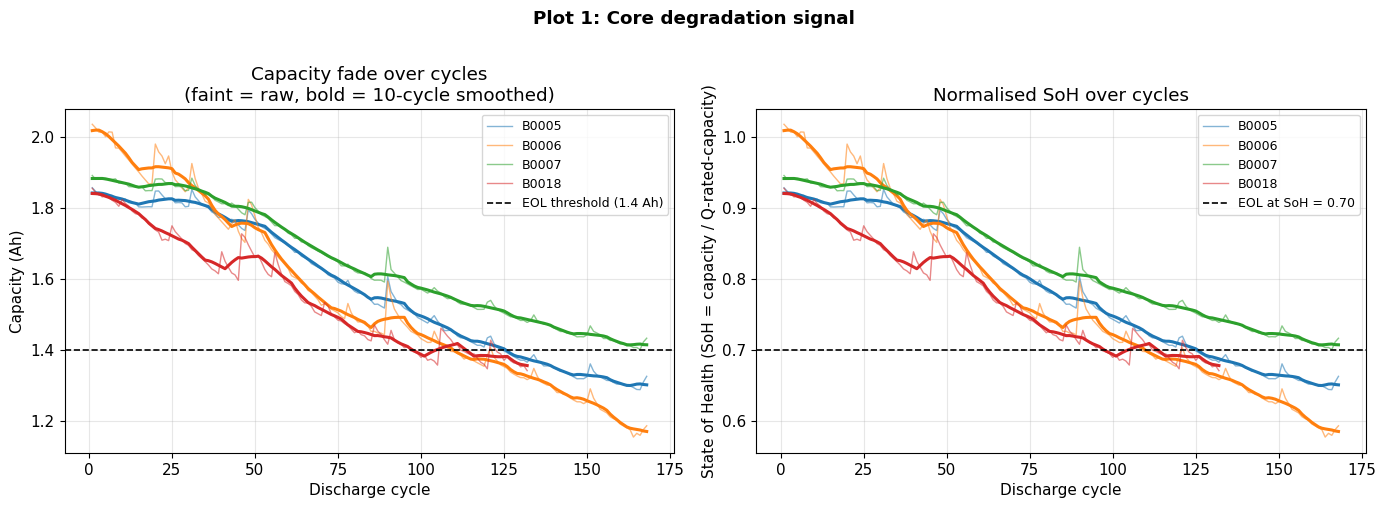

Degradation summary
         n_cycles  cap_start  cap_end  total_fade  fade_pct
battery                                                    
B0005         168      1.856    1.287       0.569    30.651
B0006         168      2.035    1.154       0.882    43.311
B0007         168      1.891    1.400       0.491    25.943
B0018         132      1.855    1.341       0.514    27.706


In [200]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw capacity per cycle
ax = axes[0]
for bat, color in BAT_COLORS.items():
    sub = cycle_capacity[cycle_capacity["battery"] == bat]
    ax.plot(sub["cycle"], sub["capacity_Ah"],
            color=color, alpha=0.55, linewidth=1.0, label=bat)
    # Overlay smoothed trend
    smoothed = uniform_filter1d(sub["capacity_Ah"].values, size=10)
    ax.plot(sub["cycle"], smoothed,
            color=color, linewidth=2.2)

ax.axhline(EOL_THRESHOLD, color="black", linestyle="--",
           linewidth=1.2, label=f"EOL threshold ({EOL_THRESHOLD} Ah)")
ax.set_xlabel("Discharge cycle")
ax.set_ylabel("Capacity (Ah)")
ax.set_title("Capacity fade over cycles\n(faint = raw, bold = 10-cycle smoothed)")
ax.legend(fontsize=9)

ax = axes[1]
for bat, color in BAT_COLORS.items():
    sub = cycle_capacity[cycle_capacity["battery"] == bat]
    ax.plot(sub["cycle"], sub["SoH"],
            color=color, alpha=0.55, linewidth=1.0, label=bat)
    smoothed = uniform_filter1d(sub["SoH"].values, size=10)
    ax.plot(sub["cycle"], smoothed,
            color=color, linewidth=2.2)

ax.axhline(EOL_THRESHOLD / 2.0, color="black", linestyle="--",
           linewidth=1.2, label="EOL at SoH = 0.70")
ax.set_xlabel("Discharge cycle")
ax.set_ylabel("State of Health (SoH = capacity / Q-rated-capacity)")
ax.set_title("Normalised SoH over cycles")
ax.legend(fontsize=9)

plt.suptitle("Plot 1: Core degradation signal", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot1_capacity_fade.png", dpi=150, bbox_inches="tight")
plt.show()

print("Degradation summary")
print(
    cycle_capacity.groupby("battery").agg(
        n_cycles=("cycle", "count"),
        cap_start=("capacity_Ah", "max"),
        cap_end=("capacity_Ah", "min"),
        total_fade=("capacity_Ah", lambda x: x.max() - x.min()),
        fade_pct=("capacity_Ah", lambda x: 100*(x.max()-x.min())/x.max()),
    ).round(3)
)

#### Observation
We observe clear capacity fade from plot 1. Battery B0006 has the mode fade at 43% in 168 cycles. This attends to the core business issue of reduction in battery capacity and the need to plan the battery replacement adequately before the 70% degredation level is reached.

Further, the peaks indicate capacity degradation is non-monotonic. This implies the use of rolling statistics to capture the peaks as indications of further degradation. The peaks are known electrochemical phenomenon called capacity regeneration, caused by lithium redistribution during rest periods between test sessions. They are real signal, not measurement error.

From right pane, we observe degradation range of B0006 is deeper than others. Since B0018 is part of test data and others form the training data, the test distribution is within the range of training distribution. Hence, the inter-battery test/train split does not affect metrics in the current configuration. Battery agnostic features are imperative to capture true patterns.

### Plot 2: Discharge voltage curves across age (the raw signal)
Plot the intr-cycle voltage curves during battery discharge. 

C:\Users\shast\AppData\Local\Temp\ipykernel_42436\4245070873.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))


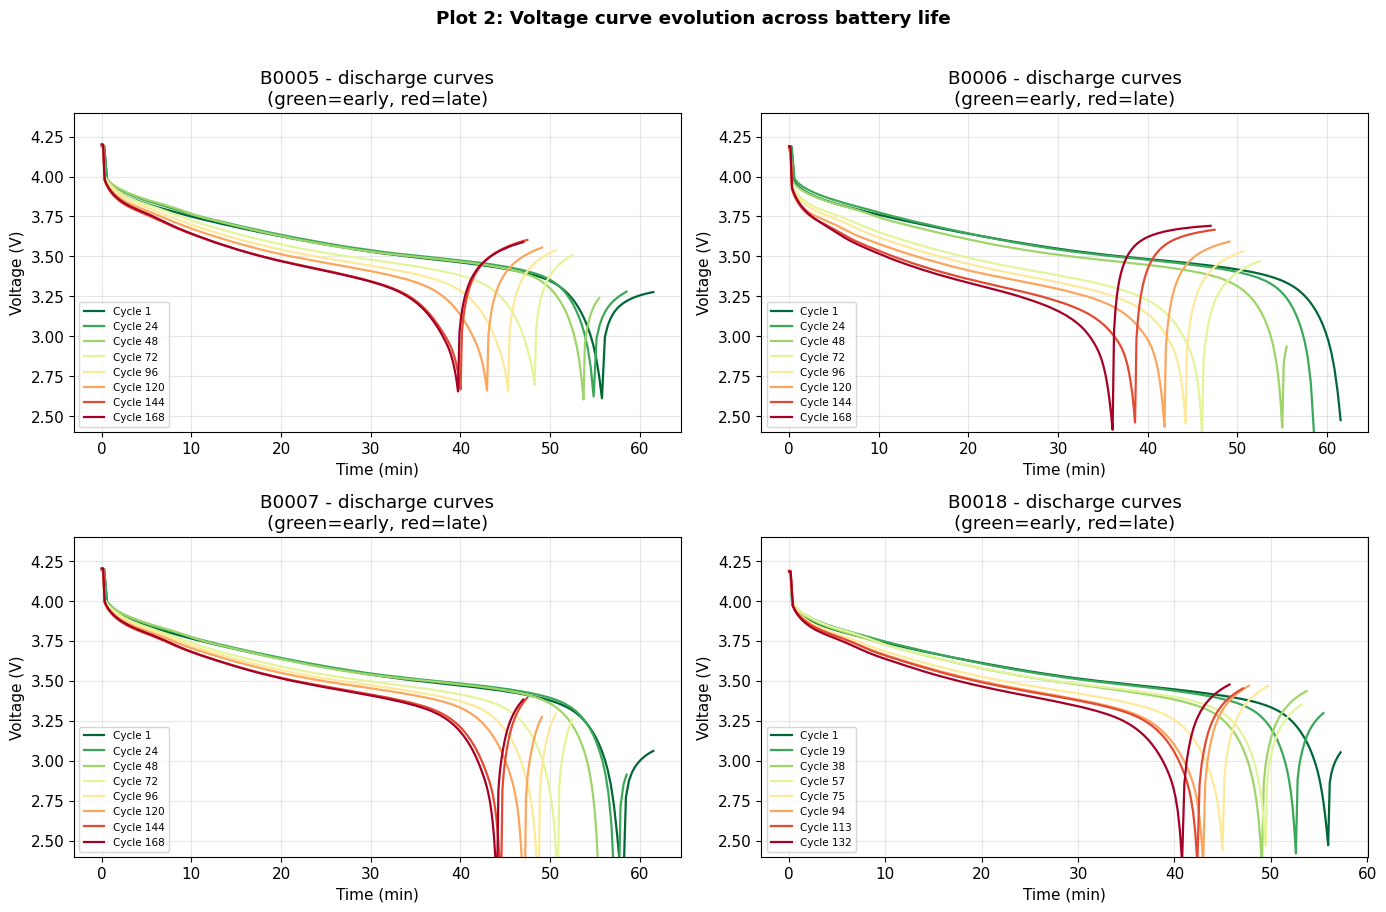

Discharge duration summary (minutes, per battery)
          min   max  mean
battery                  
B0005    46.5  61.5  52.2
B0006    46.5  61.5  52.2
B0007    46.5  61.5  52.2
B0018    45.7  57.2  51.2


In [201]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, bat in enumerate(BATTERIES):
    ax = axes[idx]
    sub = raw_df[raw_df["battery"] == bat]
    n_cycles = sub["cycle"].nunique()

    # Sample 8 representative cycles spread across the battery's life
    sample_cycles = np.linspace(1, n_cycles, 8, dtype=int)
    cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))

    for i, cyc in enumerate(sample_cycles):
        cyc_data = sub[sub["cycle"] == cyc].sort_values("Time")
        ax.plot(
            cyc_data["Time"] / 60,          # in minutes
            cyc_data["Voltage_measured"],
            color=cmap(i), linewidth=1.6,
            label=f"Cycle {cyc}"
        )

    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Voltage (V)")
    ax.set_title(f"{bat} - discharge curves\n(green=early, red=late)")
    ax.legend(fontsize=7.5, loc="lower left")
    ax.set_ylim(2.4, 4.4)

plt.suptitle("Plot 2: Voltage curve evolution across battery life", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot2_voltage_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Discharge duration summary (minutes, per battery)")
duration_df = (
    raw_df.groupby(["battery","cycle"])["Time"]
    .max()
    .reset_index()
    .rename(columns={"Time": "duration_s"})
)
duration_df["duration_min"] = duration_df["duration_s"] / 60
print(
    duration_df.groupby("battery")["duration_min"]
    .agg(["min","max","mean"])
    .round(1)
)

#### Observation
Red Curves (later cycles) have steeper initial drop (higher internal resistance), delayed plateau and reaches lowest voltage earlier. This indicates the Voltage curves clearly demarcates the aging of batteries. This proposes the usage of change in internal resistance, discharge duration, voltage slope and change in quantiles as features as these are distinct to earlier and later cycles.

### Plot 3: Temperature evolution across cycles
Plot the changes in temperature by different cycles of battery.

C:\Users\shast\AppData\Local\Temp\ipykernel_42436\342699297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))


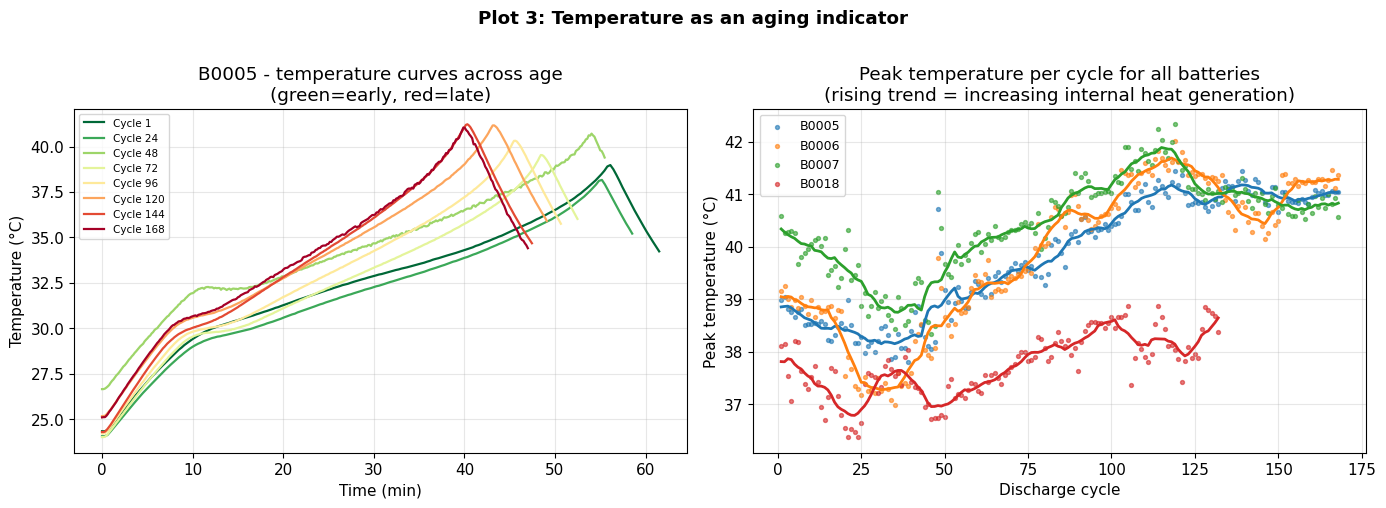

Peak temperature: first 10 vs last 10 cycles per battery
B0005:  early avg = 38.74°C  |  late avg = 41.01°C  |  rise = 2.26°C
B0006:  early avg = 38.97°C  |  late avg = 41.27°C  |  rise = 2.30°C
B0007:  early avg = 40.11°C  |  late avg = 40.82°C  |  rise = 0.71°C
B0018:  early avg = 37.71°C  |  late avg = 38.37°C  |  rise = 0.66°C


In [202]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: temperature curves for one battery across age
ax = axes[0]
bat = "B0005"
sub = raw_df[raw_df["battery"] == bat]
n_cycles = sub["cycle"].nunique()
sample_cycles = np.linspace(1, n_cycles, 8, dtype=int)
cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))

for i, cyc in enumerate(sample_cycles):
    cyc_data = sub[sub["cycle"] == cyc].sort_values("Time")
    ax.plot(cyc_data["Time"] / 60, cyc_data["Temperature_measured"],
            color=cmap(i), linewidth=1.6, label=f"Cycle {cyc}")

ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"{bat} - temperature curves across age\n(green=early, red=late)")
ax.legend(fontsize=7.5)

# Right: peak temperature per cycle for all batteries
ax = axes[1]
for bat, color in BAT_COLORS.items():
    sub = raw_df[raw_df["battery"] == bat]
    peak_temp = (
        sub.groupby("cycle")["Temperature_measured"]
        .max()
        .reset_index()
    )
    ax.scatter(peak_temp["cycle"], peak_temp["Temperature_measured"],
               color=color, s=8, alpha=0.6, label=bat)
    smoothed = uniform_filter1d(peak_temp["Temperature_measured"].values, size=10)
    ax.plot(peak_temp["cycle"], smoothed, color=color, linewidth=2.0)

ax.set_xlabel("Discharge cycle")
ax.set_ylabel("Peak temperature (°C)")
ax.set_title("Peak temperature per cycle for all batteries\n"
             "(rising trend = increasing internal heat generation)")
ax.legend(fontsize=9)

plt.suptitle("Plot 3: Temperature as an aging indicator",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot3_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

print("Peak temperature: first 10 vs last 10 cycles per battery")
for bat in BAT_COLORS:
    sub = raw_df[raw_df["battery"] == bat]
    peak = sub.groupby("cycle")["Temperature_measured"].max()
    print(f"{bat}:  early avg = {peak.iloc[:10].mean():.2f}°C  |  "
          f"late avg = {peak.iloc[-10:].mean():.2f}°C  |  "
          f"rise = {peak.iloc[-10:].mean() - peak.iloc[:10].mean():.2f}°C")

#### Observation
Clearly the initial and final temperatures vary according to cycles. This provides temperature as a physical indicative feature for training. The high inter-battery variance proposes to avoid max temperature as a feature. Relatively the rise in temperature will be a better feature for inter-battery model.

### Plot 4: Incremental capacity (dQ/dV) across age
Physics informed metric that demonstrates the rate of change of current with respect to voltage differences across cycles.

C:\Users\shast\AppData\Local\Temp\ipykernel_42436\3465990974.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))


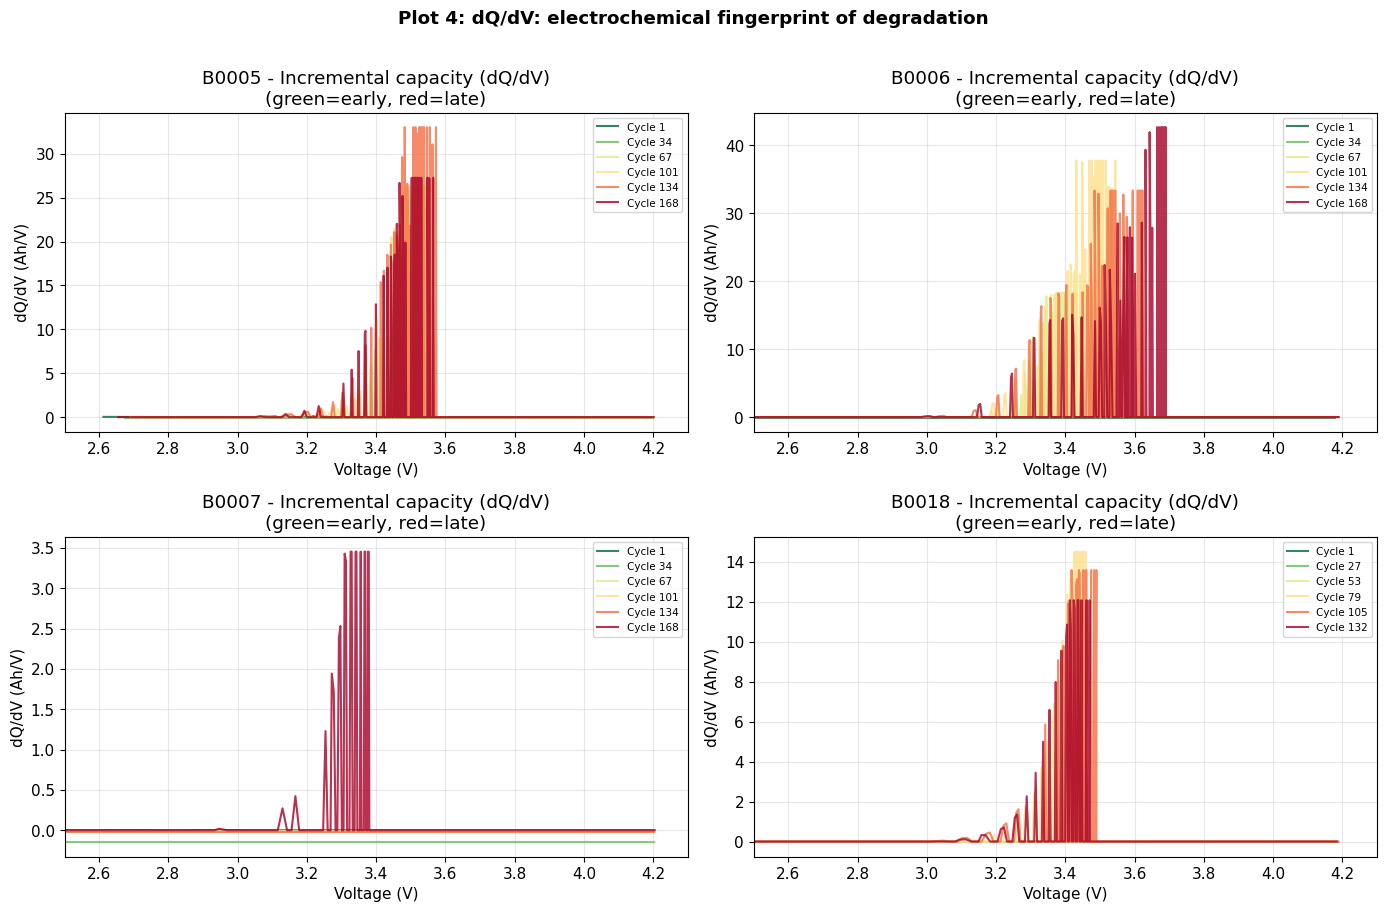

In [203]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, bat in enumerate(BATTERIES):
    ax = axes[idx]
    sub = raw_df[raw_df["battery"] == bat]
    n_cycles = sub["cycle"].nunique()
    sample_cycles = np.linspace(1, n_cycles, 6, dtype=int)
    cmap = cm.get_cmap("RdYlGn_r", len(sample_cycles))

    for i, cyc in enumerate(sample_cycles):
        cyc_data = sub[sub["cycle"] == cyc].sort_values("Voltage_measured")
        V = cyc_data["Voltage_measured"].values
        # Cumulative charge (Ah) via trapezoidal integration of |I| over time
        cyc_time = sub[sub["cycle"] == cyc].sort_values("Time")
        Q_cum = np.cumsum(
            np.abs(cyc_time["Current_measured"].values) *
            np.gradient(cyc_time["Time"].values)
        ) / 3600

        # Map Q onto the voltage-sorted axis
        sort_idx = np.argsort(cyc_time["Voltage_measured"].values)
        V_s = cyc_time["Voltage_measured"].values[sort_idx]
        Q_s = Q_cum[sort_idx]

        # Smooth before differentiating to reduce noise
        Q_smooth = uniform_filter1d(Q_s, size=8)
        with np.errstate(divide="ignore", invalid="ignore"):
            dV = np.gradient(V_s)
            dQdV = np.where(np.abs(dV) > 1e-4,
                            np.gradient(Q_smooth) / dV, 0)

        # Clip outliers for readable plot
        dQdV = np.clip(dQdV, 0, np.percentile(dQdV, 97))

        ax.plot(V_s, dQdV, color=cmap(i), linewidth=1.5,
                alpha=0.8, label=f"Cycle {cyc}")

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("dQ/dV (Ah/V)")
    ax.set_title(f"{bat} - Incremental capacity (dQ/dV)\n(green=early, red=late)")
    ax.set_xlim(2.5, 4.3)
    ax.legend(fontsize=7.5)

plt.suptitle("Plot 4: dQ/dV: electrochemical fingerprint of degradation",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot4_dqdv.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observation
In early cycles the voltage changes smoothly and gradually across the full range. Hence, dQ/dV stays low and flat with no sharp peak forms. In late cycles the battery reaches the knee region faster, and the voltage plateau becomes more pronounced relative to the total discharge duration.

feature engineering:
Based on understanding from theoretical behavior the peaks are expected in earlier cycles, but the curves show a reversed trend. The peaks present are not truly visible as they are superposed by larger jumps due to scaling. It becomes important to normalise dQdV_peak by discharge duration and compute it only over the low-voltage regionwhere the physical peak actually lives, not over the full voltage range. Voltage position (where the peak occurs on the voltage axis) can be an additional feature.

### Plot 5: Correlation heatmap of candidate features vs target
To eliminate multi-collinearity among independent variables.

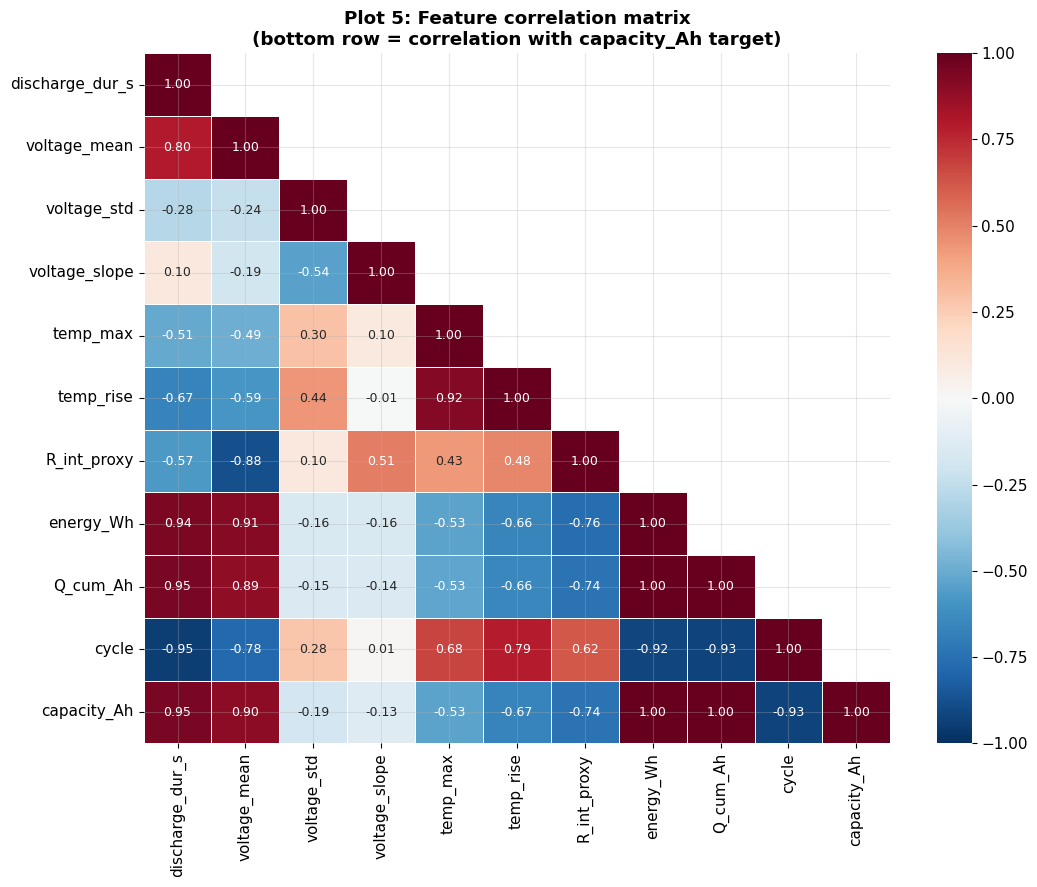

Correlation with capacity_Ah
Q_cum_Ah           0.999
energy_Wh          0.999
discharge_dur_s    0.952
cycle             -0.929
voltage_mean       0.896
R_int_proxy       -0.741
temp_rise         -0.668
temp_max          -0.534
voltage_std       -0.185
voltage_slope     -0.127
Name: capacity_Ah, dtype: float64


In [204]:
def quick_features(df_bat):
    records = []
    for (bat, cyc), grp in df_bat.groupby(["battery","cycle"]):
        grp = grp.sort_values("Time")
        V = grp["Voltage_measured"].values
        I = grp["Current_measured"].values
        T = grp["Temperature_measured"].values
        t = grp["Time"].values
        dt = np.gradient(t)

        Q_cum = np.trapezoid(np.abs(I), t) / 3600
        E_Wh = np.trapezoid(np.abs(V * I), t) / 3600
        dV_init = np.diff(V[:5]).mean()
        dI_init = np.diff(I[:5]).mean()
        R_int = abs(dV_init / dI_init) if abs(dI_init) > 1e-4 else np.nan

        records.append({
            "battery": bat,
            "cycle": cyc,
            "discharge_dur_s": t[-1] - t[0],
            "voltage_mean": V.mean(),
            "voltage_std": V.std(),
            "voltage_slope": np.polyfit(t, V, 1)[0],
            "temp_max": T.max(),
            "temp_rise": T.max() - T[0],
            "R_int_proxy": R_int,
            "energy_Wh": E_Wh,
            "Q_cum_Ah": Q_cum,
            "capacity_Ah": grp["capacity_Ah"].iloc[0]
        })
    return pd.DataFrame(records)

feat_preview = quick_features(raw_df)

feat_cols = ["discharge_dur_s","voltage_mean","voltage_std","voltage_slope",
             "temp_max","temp_rise","R_int_proxy","energy_Wh","Q_cum_Ah","cycle"]

corr = feat_preview[feat_cols + ["capacity_Ah"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # show lower triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 9}
)
ax.set_title("Plot 5: Feature correlation matrix\n"
             "(bottom row = correlation with capacity_Ah target)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("./assets/plot5_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with capacity_Ah")
print(
    corr["capacity_Ah"]
    .drop("capacity_Ah")
    .sort_values(key=abs, ascending=False)
    .round(3)
)

#### Observation
Multi-collinearity causes redundant features for linear modelling. Parameters across features become sensitive to each other it violates the assumption of independent variables in linear baseline. But as ensemble models are less affected all three features can be retained.

### Plot 6: Per-battery degradation comparison 
Validates the cross-battery split strategy for training and test.

KeyError: 'B0036'

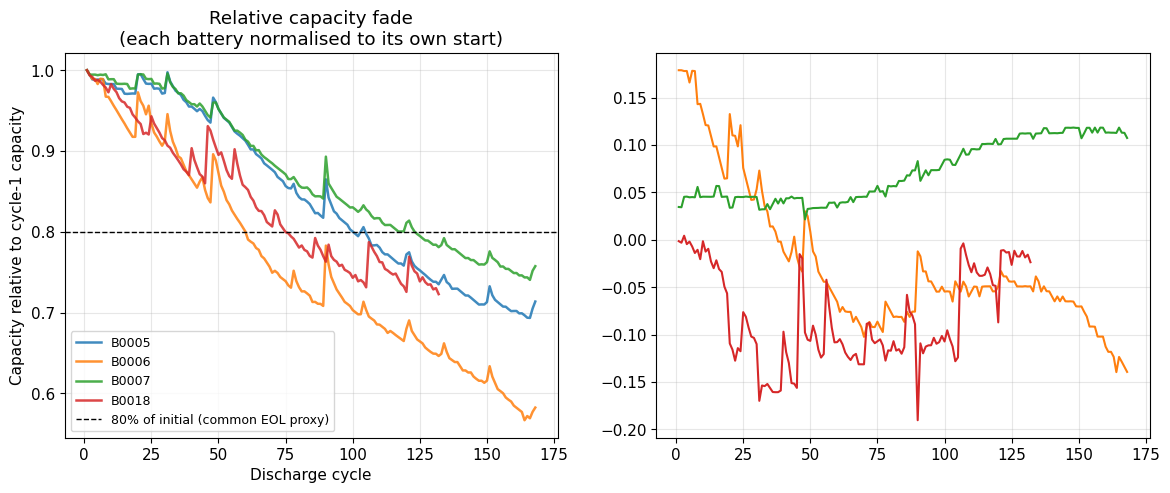

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay normalised to each battery's own starting capacity
ax = axes[0]
for bat, color in BAT_COLORS.items():
    sub = cycle_capacity[cycle_capacity["battery"] == bat].copy()
    sub["SoH_relative"] = sub["capacity_Ah"] / sub["capacity_Ah"].iloc[0]
    ax.plot(sub["cycle"], sub["SoH_relative"],
            color=color, linewidth=1.8, label=bat, alpha=0.85)

ax.axhline(0.80, color="black", linestyle="--", linewidth=1.0,
           label="80% of initial (common EOL proxy)")
ax.set_xlabel("Discharge cycle")
ax.set_ylabel("Capacity relative to cycle-1 capacity")
ax.set_title("Relative capacity fade\n(each battery normalised to its own start)")
ax.legend(fontsize=9)

# Right: cycle-by-cycle difference between batteries (B0005 as reference)
ax = axes[1]
ref = (cycle_capacity[cycle_capacity["battery"] == "B0005"]
       .set_index("cycle")["capacity_Ah"])

for bat in ["B0006", "B0007", "B0018", "B0036"]:
    sub = (cycle_capacity[cycle_capacity["battery"] == bat]
           .set_index("cycle")["capacity_Ah"])
    common = ref.index.intersection(sub.index)
    diff = sub.loc[common] - ref.loc[common]
    ax.plot(common, diff, color=BAT_COLORS[bat],
            linewidth=1.5, label=f"{bat} − B0005")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Discharge cycle")
ax.set_ylabel("Capacity difference vs B0005 (Ah)")
ax.set_title("Inter-battery divergence\n(B0005 as reference)")
ax.legend(fontsize=9)

plt.suptitle("Plot 6: Cross-battery comparison (validates holdout split)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./assets/plot6_battery_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Capacity loss per 10 cycles")
for bat in BAT_COLORS:
    sub = cycle_capacity[cycle_capacity["battery"] == bat]
    slope = np.polyfit(sub["cycle"], sub["capacity_Ah"], 1)[0]
    print(f"{bat}:  {slope*10:.4f} Ah / 10 cycles")

#### Observation
This indicates large variance across batteries during early and late phases. Cycle level RMSE is a necessity. Also, battery type encoding features should be avoided such as cycle sequence.

### EDA summary:

1. Degradation is real, measurable and non-linear. Requires complex models that accounts for non-linear relations.
2. The raw signals do carry the aging signal. But requre feature engineering to avoid pitfalls.
3. B0018 is a legitimate holdout. Its degradation trajectory differs from the training batteries in rate and shape, making the cross-battery split a genuine generalisation test rather than an easy one.
4. Key features are highly correlated with the target. Ex: discharge duration, cumulative charge, and energy. Physics-informed features like internal resistance and temp rise provide additional signal shape info.

# DATA PREPARATION

## Feature Engineering

In [206]:
# reference physical static data 
T_REF = 24.0   # reference ambient temperature (°C)
ALPHA = 0.005  # capacity temperature coefficient for LiCoO2 (Ah/°C)
VMIN_DQDV = 2.7 # voltage window for dQ/dV peak extraction
VMAX_DQDV = 3.7

def extract_cycle_features(grp):
    V  = grp["Voltage_measured"].values
    I  = grp["Current_measured"].values
    T  = grp["Temperature_measured"].values
    t  = grp["Time"].values
    T_amb = grp["ambient_temp_C"].iloc[0]

    # Statistical Features
    discharge_dur_s = t[-1] - t[0]
    voltage_mean = V.mean()
    voltage_std = V.std()
    voltage_slope = np.polyfit(t, V, 1)[0]   # V/s: encodes non-linear relations

    # Voltage at 80% of discharge duration: position-specific snapshot
    idx_80 = int(0.80 * len(t))
    voltage_at_80pct = V[idx_80]

    # temp_rise: [peak-start] to remove inter-battery ambient offset
    temp_rise = T.max() - T[0]

    # Physics-Informed features

    # Internal resistance at early stage: dV/dI at cycle start (first 10 steps)
    dV = np.diff(V[:10]).mean()
    dI = np.diff(I[:10]).mean()
    R_int_proxy = abs(dV / dI) if abs(dI) > 1e-4 else np.nan

    # Energy delivered this cycle (Wh)
    energy_Wh = np.trapezoid(np.abs(V * I), t) / 3600

    # Cumulative charge delivered (Ah)
    Q_cum_Ah = np.trapezoid(np.abs(I), t) / 3600

    # Temperature-compensated capacity
    #  Normalises Q_cum_Ah for ambient temperature drift across cycles
    #  Formula: Q_norm = Q / (1 + alpha * (T_amb - T_ref))
    Q_temp_compensated = Q_cum_Ah / (1 + ALPHA * (T_amb - T_REF))

    # dQ/dV peak features: computed over low-voltage window only
    mask = (V >= VMIN_DQDV) & (V <= VMAX_DQDV)
    dQdV_peak_height  = np.nan
    dQdV_peak_voltage = np.nan

    if mask.sum() > 10:
        V_win = V[mask]
        I_win = I[mask]
        t_win = t[mask]

        # Sort by voltage (ascending) for dQ/dV computation
        sort_idx = np.argsort(V_win)
        V_s = V_win[sort_idx]
        t_s = t_win[sort_idx]
        I_s = I_win[sort_idx]

        # Cumulative charge in this window
        Q_s = np.cumsum(np.abs(I_s) * np.gradient(t_s)) / 3600

        # Smooth Q before differentiating to reduce numerical noise
        Q_smooth = uniform_filter1d(Q_s, size=max(3, len(Q_s) // 15))

        dV_arr = np.gradient(V_s)
        with np.errstate(divide="ignore", invalid="ignore"):
            dQdV = np.where(np.abs(dV_arr) > 1e-5, np.gradient(Q_smooth) / dV_arr, 0)

        # Clip top 2% to suppress remaining noise spikes
        dQdV = np.clip(dQdV, 0, np.percentile(dQdV, 98))

        # Normalise by discharge duration
        dQdV_norm = dQdV / (discharge_dur_s / 3600)

        peak_idx = np.argmax(dQdV_norm)
        dQdV_peak_height  = dQdV_norm[peak_idx]
        dQdV_peak_voltage = V_s[peak_idx]

    return {
        # Statistical
        "discharge_dur_s": discharge_dur_s,
        "voltage_mean": voltage_mean,
        "voltage_std": voltage_std,
        "voltage_slope": voltage_slope,
        "voltage_at_80pct": voltage_at_80pct,
        "temp_rise": temp_rise,
        # Physics-informed
        "R_int_proxy": R_int_proxy,
        "energy_Wh": energy_Wh,
        "Q_cum_Ah": Q_cum_Ah,
        "Q_temp_compensated": Q_temp_compensated,
        "dQdV_peak_height": dQdV_peak_height,
        "dQdV_peak_voltage": dQdV_peak_voltage
    }

### Generate features from function

In [207]:
# generate
records = []
for (bat, cyc), grp in raw_df.groupby(["battery", "cycle"]):
    grp_sorted = grp.sort_values("Time")
    feat = extract_cycle_features(grp_sorted)
    feat["battery"] = bat
    feat["cycle"] = cyc
    feat["capacity_Ah"] = grp_sorted["capacity_Ah"].iloc[0]
    records.append(feat)

feature_df = pd.DataFrame(records)

# Add rolling statistics
feature_df = feature_df.sort_values(["battery", "cycle"]).reset_index(drop=True)

for bat in feature_df["battery"].unique():
    mask = feature_df["battery"] == bat
    cap  = feature_df.loc[mask, "capacity_Ah"]

    feature_df.loc[mask, "rolling_mean_5"] = cap.shift(1).rolling(window=5, min_periods=1).mean()
    feature_df.loc[mask, "rolling_std_5"] = cap.shift(1).rolling(window=5, min_periods=1).std().fillna(0)

feature_df["rolling_mean_5"] = (
    feature_df.groupby("battery")["rolling_mean_5"]
    .transform(lambda x: x.bfill())
)
feature_df["dQdV_peak_height"] = feature_df["dQdV_peak_height"].clip(lower=0)
feature_df

,discharge_dur_s,voltage_mean,voltage_std,voltage_slope,voltage_at_80pct,temp_rise,R_int_proxy,energy_Wh,Q_cum_Ah,Q_temp_compensated,dQdV_peak_height,dQdV_peak_voltage,battery,cycle,capacity_Ah,rolling_mean_5,rolling_std_5
0,3690.234,3.529829,0.235957,-0.000206,3.376548,14.652147,0.155626,6.608778,1.862203,1.862203,0.274616,3.233103,B0005,1,1.856487,1.856487,0.000000
1,3672.344,3.537320,0.234765,-0.000205,3.388104,14.335646,0.151086,6.586345,1.852078,1.852078,0.268305,3.250605,B0005,2,1.846327,1.856487,0.000000
2,3651.641,3.543737,0.227525,-0.000200,3.387797,14.084531,0.149003,6.555683,1.841049,1.841049,0.320827,3.284359,B0005,3,1.835349,1.851407,0.007184
3,3631.563,3.543666,0.232744,-0.000205,3.393338,14.108068,0.148156,6.554829,1.840912,1.840912,0.303970,3.260823,B0005,4,1.835263,1.846055,0.010572
4,3629.172,3.542343,0.236689,-0.000208,3.393330,14.140596,0.147958,6.552232,1.840360,1.840360,0.270573,3.257652,B0005,5,1.834646,1.843357,0.010180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,2777.844,3.455229,0.264114,-0.000282,3.195361,15.128331,0.164162,4.789447,1.382002,1.382002,14.653592,3.378008,B0018,128,1.362737,1.380056,0.010898
632,2781.125,3.461974,0.253917,-0.000270,3.190439,14.753149,0.163046,4.771233,1.375103,1.375103,14.766632,3.385699,B0018,129,1.363405,1.373906,0.010067
633,2760.906,3.452222,0.259242,-0.000275,3.179275,15.164103,0.165914,4.717904,1.363526,1.363526,15.619980,3.363267,B0018,130,1.351865,1.368937,0.006827
634,2753.250,3.447650,0.270182,-0.000291,3.193502,15.270443,0.165663,4.750723,1.374234,1.374234,16.130440,3.384601,B0018,131,1.354797,1.365272,0.010114


In [208]:
print("feature shape")
print(feature_df.shape)

print("\nNulls")
nulls = feature_df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No nulls")

print("\nfeature stats")
feat_cols = [
    "discharge_dur_s","voltage_mean","voltage_std","voltage_slope",
    "voltage_at_80pct","temp_rise","R_int_proxy","energy_Wh",
    "Q_cum_Ah","Q_temp_compensated","dQdV_peak_height",
    "dQdV_peak_voltage","rolling_mean_5","rolling_std_5"
]
print(feature_df[feat_cols].describe().round(4))

print("\nsamples by battery")
print(feature_df.groupby("battery").size().rename("n_cycles"))

print(feature_df[["battery","cycle"] + feat_cols + ["capacity_Ah"]].head().to_string(index=False))

feature shape
(636, 17)

Nulls
No nulls

feature stats
       discharge_dur_s  voltage_mean  voltage_std  voltage_slope  \
count         636.0000      636.0000     636.0000       636.0000   
mean         3116.9777        3.4986       0.2472        -0.0002   
std           242.1972        0.0475       0.0167         0.0000   
min          2742.8430        3.4039       0.2171        -0.0003   
25%          2891.9962        3.4667       0.2339        -0.0003   
50%          3084.2810        3.5025       0.2441        -0.0002   
75%          3311.8280        3.5411       0.2583        -0.0002   
max          3690.2340        3.5736       0.2922        -0.0001   

       voltage_at_80pct  temp_rise  R_int_proxy  energy_Wh  Q_cum_Ah  \
count          636.0000   636.0000     636.0000   636.0000  636.0000   
mean             3.2811    15.6235       0.1494     5.5931    1.5947   
std              0.1602     1.2328       0.0162     0.7712    0.1985   
min              2.5835    12.9930       0.1

### Train/Test Split
The battery data on B0018 is chosen as holdout set while the other batteries serve as the training dataset.

In [209]:
# Split by battery ID
# B0018 is the holdout: the model has never seen this battery during training.

TRAIN_BATTERIES = ["B0005", "B0006", "B0007", "B0036"]
TEST_BATTERY = "B0018"

train_df = feature_df[feature_df["battery"].isin(TRAIN_BATTERIES)].copy()
test_df = feature_df[feature_df["battery"] == TEST_BATTERY].copy()

X_train = train_df[feat_cols]
y_train = train_df["capacity_Ah"]
X_test = test_df[feat_cols]
y_test = test_df["capacity_Ah"]

print(f"Train : {X_train.shape[0]} cycles  "
      f"| capacity range {y_train.min():.4f}–{y_train.max():.4f} Ah")
print(f"Test  : {X_test.shape[0]} cycles  "
      f"| capacity range {y_test.min():.4f}–{y_test.max():.4f} Ah")
print(f"Features : {len(feat_cols)}")

Train : 504 cycles  | capacity range 1.1538–2.0353 Ah
Test  : 132 cycles  | capacity range 1.3411–1.8550 Ah
Features : 14


# MODEL BUILDING

## Initialize Models
Initialize the 3 models as a pipeline to avoid data leakage.

In [232]:
# Initialize Pipeline
pipelines = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=1.0))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(n_estimators = 200, max_depth = None, min_samples_leaf = 2, 
                                         random_state = RANDOM_STATE,n_jobs = -1)
        )
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4, subsample = 0.8, reg_alpha = 0.1,
                                colsample_bytree = 0.8, random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1
        ))
    ]),
}

## Group K-Fold Validation
Train on 2 batteries with one full battery set as hold out.

In [233]:
# Group Kfold: battery type/ID as folds
# With 3 training batteries this is leave-one-battery-out CV.

groups = train_df["battery"].values
n_splits_var = int(len(groups.unique()))
gkf = GroupKFold(n_splits=n_splits_var)

cv_results = {}
print(f"Cross-validation (GroupKFold, {n_splits_var} folds)")

for name, pipe in pipelines.items():
    cv = cross_validate(
        pipe, X_train, y_train,
        cv = gkf,
        groups = groups,
        scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"],
        return_train_score = True,
        n_jobs = -1
    )
    rmse_val = -cv["test_neg_root_mean_squared_error"]
    mae_val = -cv["test_neg_mean_absolute_error"]
    rmse_train = -cv["train_neg_root_mean_squared_error"]

    cv_results[name] = {
        "cv_rmse_mean": rmse_val.mean(),
        "cv_rmse_std": rmse_val.std(),
        "cv_mae_mean": mae_val.mean(),
        "cv_train_rmse": rmse_train.mean(),
    }
    print(f"\n{name}")
    print(f"  Train RMSE (mean): {rmse_train.mean():.4f} Ah")
    print(f"  Val RMSE (mean): {rmse_val.mean():.4f} Ah  ±{rmse_val.std():.4f}")
    print(f"  Val MAE (mean): {mae_val.mean():.4f} Ah")
    gap = rmse_val.mean() - rmse_train.mean()
    print(f"  Generalisation gap (val−train RMSE): {gap:.4f} Ah"
          f"  {'possible overfit' if gap > 0.05 else 'Overfitting'}")
    
    print(f"  Val RMSE by Battery:")
    print(groups.unique())
    print(rmse_val)

Cross-validation (GroupKFold, 3 folds)

Ridge
  Train RMSE (mean): 0.0029 Ah
  Val RMSE (mean): 0.0140 Ah  ±0.0078
  Val MAE (mean): 0.0120 Ah
  Generalisation gap (val−train RMSE): 0.0111 Ah  Overfitting
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.00615633 0.02467226 0.01112061]

RandomForest
  Train RMSE (mean): 0.0023 Ah
  Val RMSE (mean): 0.0269 Ah  ±0.0191
  Val MAE (mean): 0.0200 Ah
  Generalisation gap (val−train RMSE): 0.0245 Ah  Overfitting
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.01500302 0.0537557  0.01180633]

XGBoost
  Train RMSE (mean): 0.0037 Ah
  Val RMSE (mean): 0.0322 Ah  ±0.0242
  Val MAE (mean): 0.0241 Ah
  Generalisation gap (val−train RMSE): 0.0285 Ah  Overfitting
  Val RMSE by Battery:
<ArrowStringArray>
['B0005', 'B0006', 'B0007']
Length: 3, dtype: str
[0.01184839 0.06621301 0.01852953]


## Test on hold out set
Test the models on 4th Battery (B0018) to assess the model performance on unseen data.

In [234]:
print(f"\nHoldout evaluation on {TEST_BATTERY}")
trained = {}
holdout_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    y_pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)

    holdout_results[name] = {
        "rmse": rmse,
        "mae": mae,
        "y_pred": y_pred
    }
    print(f"{name:>14}  RMSE: {rmse:.4f} Ah   MAE: {mae:.4f} Ah")


Holdout evaluation on B0018
         Ridge  RMSE: 0.0051 Ah   MAE: 0.0045 Ah
  RandomForest  RMSE: 0.0068 Ah   MAE: 0.0052 Ah
       XGBoost  RMSE: 0.0069 Ah   MAE: 0.0057 Ah


### Grid Search with groupK fold to tune XGBoost hyperparameters

In [236]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.05, 0.06],
    "model__min_child_weight": [3, 5, 10],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_alpha": [0.1, 0.5],
    "model__reg_lambda": [0.0],
}

xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(random_state = RANDOM_STATE, verbosity = 0, n_jobs = -1,
    ))
])

gkf = GroupKFold(n_splits=3)
groups = train_df["battery"].values

## randomly sample 50 combinations to reduce computation
search = GridSearchCV(estimator = xgb_pipe, param_grid = param_grid, 
                            scoring = "neg_root_mean_squared_error", cv = gkf, refit = True,
                            n_jobs = -1, verbose = 1)

search.fit(X_train, y_train, groups=groups)

print("Best parameters")
for param, value in search.best_params_.items():
    print(f"  {param:<30} {value}")

print(f"\nBest CV RMSE : {-search.best_score_:.4f} Ah")

# Evaluate best model on B0018
y_pred_best = search.predict(X_test)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
mae_best = mean_absolute_error(y_test, y_pred_best)
print(f"B0018 RMSE: {rmse_best:.4f} Ah")
print(f"B0018 MAE: {mae_best:.4f} Ah")

# Check for overfitting
best_pipe = search.best_estimator_
y_pred_train = best_pipe.predict(X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
print(f"\nTrain RMSE: {rmse_train:.4f} Ah")
print(f"Val RMSE: {-search.best_score_:.4f} Ah")
print(f"Ratio: {(-search.best_score_) / rmse_train:.1f}×  "
      f"{'no overfitting' if (-search.best_score_) / rmse_train < 10 else 'still overfitting'}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters
  model__colsample_bytree        0.8
  model__learning_rate           0.06
  model__max_depth               3
  model__n_estimators            300
  model__reg_alpha               0.1
  model__reg_lambda              0.0
  model__subsample               0.8

Best CV RMSE : 0.0296 Ah
B0018 RMSE: 0.0077 Ah
B0018 MAE: 0.0065 Ah

Train RMSE: 0.0036 Ah
Val RMSE: 0.0296 Ah
Ratio: 8.2×  no overfitting


In [219]:
# Top Combinations
print("\nTop 10 combinations by CV RMSE")
results_df = pd.DataFrame(search.cv_results_)
top10 = (
    results_df
    .sort_values("rank_test_score")
    .head(10)[[
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
        "param_model__min_child_weight",
        "param_model__subsample",
        "param_model__colsample_bytree",
        "param_model__reg_alpha",
        "param_model__reg_lambda",
        "mean_test_score",
        "std_test_score",
    ]]
    .rename(columns={
        "param_model__n_estimators":"n_est",
        "param_model__max_depth":"depth",
        "param_model__learning_rate":"lr",
        "param_model__min_child_weight":"min_child",
        "param_model__subsample":"subsample",
        "param_model__colsample_bytree":"col_sample",
        "param_model__reg_alpha":"alpha",
        "param_model__reg_lambda":"lambda",
        "mean_test_score":"cv_rmse",
        "std_test_score":"std",
    })
)
top10["cv_rmse"] = (-top10["cv_rmse"]).round(4)
top10["std"] = top10["std"].round(4)
print(top10.to_string(index=False))

xgb_final = search.best_estimator_
xgb_final_pred = y_pred_best

print("\nReady for Bucket 5")
print(f"Final model: XGBoost with best params above")
print(f"B0018 RMSE: {rmse_best:.4f} Ah")


Top 10 combinations by CV RMSE
 n_est  depth   lr  min_child  subsample  col_sample  alpha  lambda  cv_rmse    std
   300      2 0.06          3        0.8         0.8    0.1     5.0   0.0304 0.0239
   300      2 0.06          5        0.8         0.8    0.1     5.0   0.0305 0.0239
   200      2 0.06          3        0.8         0.8    0.1     5.0   0.0305 0.0240
   200      2 0.06          5        0.8         0.8    0.1     5.0   0.0305 0.0240
   300      2 0.05          3        0.8         0.8    0.1     5.0   0.0306 0.0243
   300      2 0.05          5        0.8         0.8    0.1     5.0   0.0306 0.0243
   300      4 0.06          3        0.8         0.8    0.1     5.0   0.0307 0.0236
   200      2 0.05          3        0.8         0.8    0.1     5.0   0.0308 0.0245
   200      4 0.06          3        0.8         0.8    0.1     5.0   0.0308 0.0237
   200      2 0.05          5        0.8         0.8    0.1     5.0   0.0308 0.0245

Ready for Bucket 5
Final model: XGBoost wit

## Generate the metrics to analyse
For each cycle zone: early, mid and late, generate the results. Analysis at 3 zones to minimize the impact of inter-battery variance. 

In [220]:
print("\nRMSE by life phase on B0018")
cycles_test = test_df["cycle"].values
phases = {
    "Early (1–44)": (cycles_test >= 1)  & (cycles_test <= 44),
    "Mid (45–88)": (cycles_test >= 45) & (cycles_test <= 88),
    "Late (89–132)": (cycles_test >= 89) & (cycles_test <= 132),
}

phase_rows = []
for name in pipelines:
    y_pred = holdout_results[name]["y_pred"]
    row = {"Model": name}
    for phase_label, mask in phases.items():
        rmse_p = mean_squared_error(y_test.values[mask], y_pred[mask]) ** 0.5
        row[phase_label] = round(rmse_p, 4)
    phase_rows.append(row)

phase_df = pd.DataFrame(phase_rows).set_index("Model")
print(phase_df.to_string())


RMSE by life phase on B0018
              Early (1–44)  Mid (45–88)  Late (89–132)
Model                                                 
Ridge               0.0047       0.0060         0.0046
RandomForest        0.0050       0.0074         0.0077
XGBoost             0.0061       0.0079         0.0079


## Model Level Comparison
Compare the RMSE and MAE of the 3 models to analyse the performance.

In [221]:
print("\nFull model comparison")
rows = []
for name in pipelines:
    rows.append({
        "Model": name,
        "CV RMSE (mean)": round(cv_results[name]["cv_rmse_mean"], 4),
        "CV RMSE (±std)": round(cv_results[name]["cv_rmse_std"],  4),
        "CV MAE": round(cv_results[name]["cv_mae_mean"],   4),
        "B0018 RMSE": round(holdout_results[name]["rmse"],     4),
        "B0018 MAE": round(holdout_results[name]["mae"],      4),
    })
comparison_df = pd.DataFrame(rows).set_index("Model")
print(comparison_df.to_string())


Full model comparison
              CV RMSE (mean)  CV RMSE (±std)  CV MAE  B0018 RMSE  B0018 MAE
Model                                                                      
Ridge                 0.0140          0.0078  0.0120      0.0051     0.0045
RandomForest          0.0269          0.0191  0.0200      0.0068     0.0052
XGBoost               0.0291          0.0237  0.0227      0.0074     0.0061


## Residual Plots

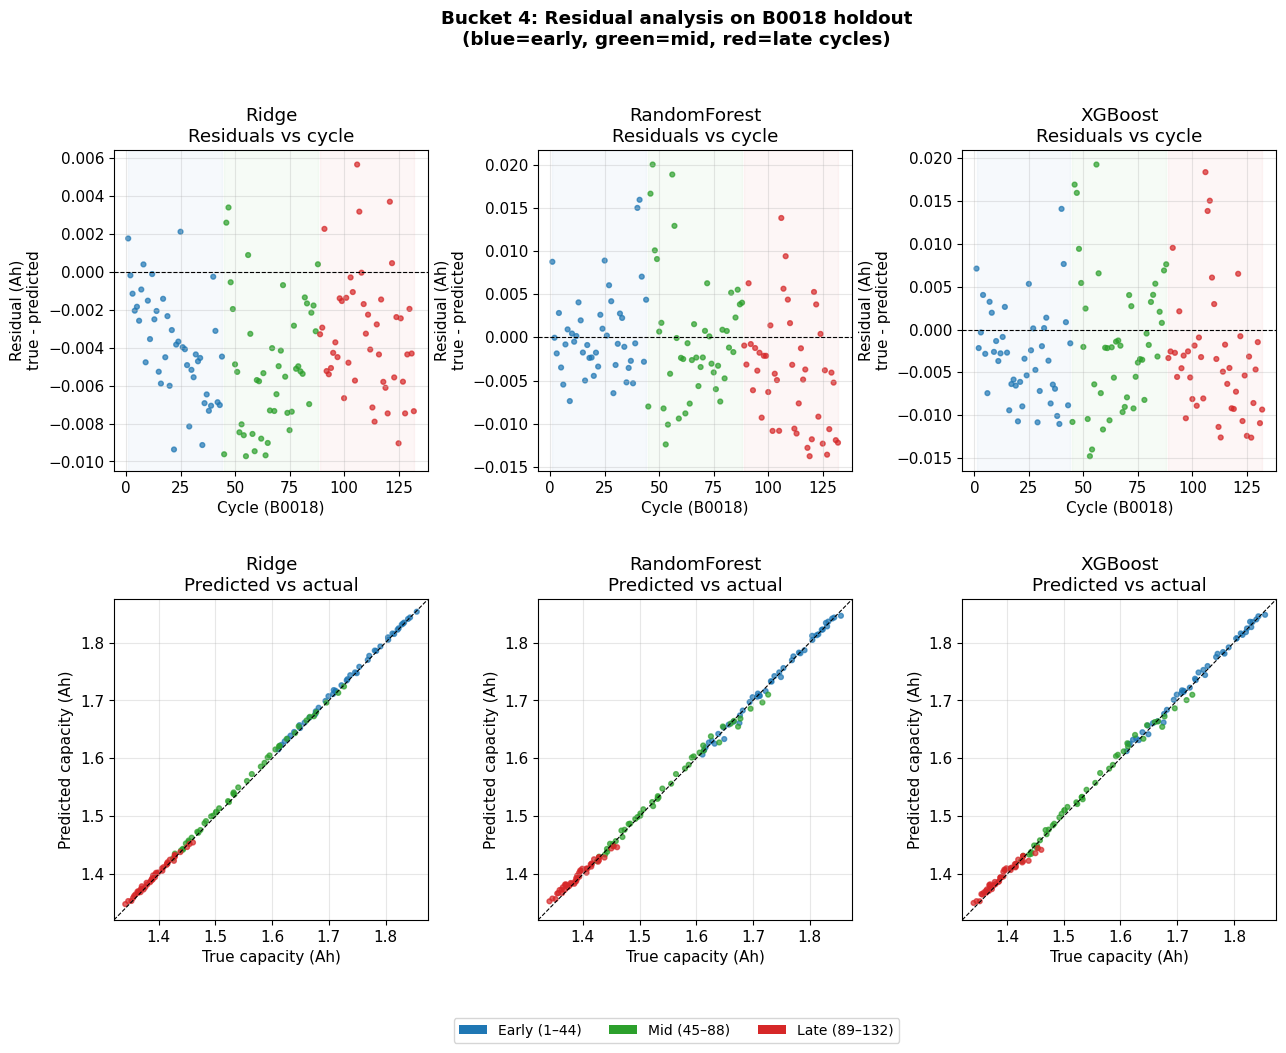

In [222]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

cycles_test = test_df["cycle"].values
y_true      = y_test.values

for col, name in enumerate(pipelines):
    y_pred    = holdout_results[name]["y_pred"]
    residuals = y_true - y_pred   # positive = under-prediction

    # Top row: residuals vs cycle number
    ax_top = fig.add_subplot(gs[0, col])
    colors = np.where(cycles_test <= 44, "#1f77b4",
             np.where(cycles_test <= 88, "#2ca02c", "#d62728"))
    ax_top.scatter(cycles_test, residuals, c=colors, s=12, alpha=0.7)
    ax_top.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_top.set_xlabel("Cycle (B0018)")
    ax_top.set_ylabel("Residual (Ah)\ntrue - predicted")
    ax_top.set_title(f"{name}\nResiduals vs cycle")
    # Phase shading
    ax_top.axvspan(1,  44,  alpha=0.04, color="#1f77b4")
    ax_top.axvspan(45, 88,  alpha=0.04, color="#2ca02c")
    ax_top.axvspan(89, 132, alpha=0.04, color="#d62728")

    # Bottom row: predicted vs actual
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.scatter(y_true, y_pred, c=colors, s=12, alpha=0.7)
    lims = [min(y_true.min(), y_pred.min()) - 0.02,
            max(y_true.max(), y_pred.max()) + 0.02]
    ax_bot.plot(lims, lims, "k--", linewidth=0.8, label="Perfect prediction")
    ax_bot.set_xlabel("True capacity (Ah)")
    ax_bot.set_ylabel("Predicted capacity (Ah)")
    ax_bot.set_title(f"{name}\nPredicted vs actual")
    ax_bot.set_xlim(lims); ax_bot.set_ylim(lims)

# Legend for life phase colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1f77b4", label="Early (1–44)"),
    Patch(facecolor="#2ca02c", label="Mid (45–88)"),
    Patch(facecolor="#d62728", label="Late (89–132)"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Bucket 4: Residual analysis on B0018 holdout\n"
             "(blue=early, green=mid, red=late cycles)",
             fontweight="bold", y=1.02)
plt.savefig("./assets/plot7_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observation:
1. Ridge's early-cycle bias is interpretable and honest. It reflects a real inter-battery difference, not a model failure. The correct statement in your write-up is: "Ridge over-predicts B0018 capacity in early cycles because B0018's initial capacity (1.855 Ah) is lower than the training battery mean. A model without battery-specific calibration will anchor to the training distribution."
2. Ensemble mid-cycle bias reveals overfit pattern matching. RF and XGBoost learned the specific shape of training battery degradation curves including their recovery bumps. When B0018's recovery pattern differs, the models mis-predict. This is the practical consequence of the 41× train/val ratio identified in Bucket 4.
3. All models are operationally reliable in the late-life region. Red points cluster tightly on the diagonal for all three models — the EOL region (1.34–1.45 Ah) is predicted accurately. For a real BMS application this is the region that matters most, so all three models would be deployable for end-of-life detection despite their mid-life errors.

# MODEL EVALUATION

In [ ]:
# Cycle Level Metrics
cycles_test = test_df["cycle"].values
y_true = y_test.values

phases = {
    "Early (1–44)":(cycles_test >= 1)  & (cycles_test <= 44),
    "Mid (45–88)":(cycles_test >= 45) & (cycles_test <= 88),
    "Late (89–132)":(cycles_test >= 89) & (cycles_test <= 132)
}

# Summary
print("Holdout metrics (B0018)")
full_rows = []
for name in ["Ridge", "RandomForest", "XGBoost"]:
    y_pred = holdout_results[name]["y_pred"]
    resid  = y_true - y_pred
    full_rows.append({
        "Model": name,
        "RMSE": round(mean_squared_error(y_true, y_pred)**0.5, 4),
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "R²": round(r2_score(y_true, y_pred), 5),
        "Bias(mean)": round(resid.mean(), 5),   # systematic over/under prediction
        "Resid std": round(resid.std(), 5),     # spread of errors
        "Max |err|": round(np.abs(resid).max(), 4),
    })
full_df = pd.DataFrame(full_rows).set_index("Model")
print(full_df.to_string())

Holdout metrics (B0018)
                RMSE     MAE       R²  Bias(mean)  Resid std  Max |err|
Model                                                                  
Ridge         0.0051  0.0045  0.99889    -0.00405    0.00318     0.0097
RandomForest  0.0068  0.0052  0.99806    -0.00124    0.00668     0.0200
XGBoost       0.0069  0.0057  0.99798    -0.00238    0.00651     0.0178


In [240]:
# Phase Level Metrics

print("\nPhase-level RMSE and bias (B0018)")
phase_rows = []
for name in ["Ridge", "RandomForest", "XGBoost"]:
    y_pred = holdout_results[name]["y_pred"]
    row    = {"Model": name}
    for label, mask in phases.items():
        resid_p = y_true[mask] - y_pred[mask]
        row[f"{label} RMSE"] = round(mean_squared_error(y_true[mask], y_pred[mask])**0.5, 4)
        row[f"{label} bias"] = round(resid_p.mean(), 4)
    phase_rows.append(row)

phase_df = pd.DataFrame(phase_rows).set_index("Model")
print(phase_df.to_string())


Phase-level RMSE and bias (B0018)
              Early (1–44) RMSE  Early (1–44) bias  Mid (45–88) RMSE  Mid (45–88) bias  Late (89–132) RMSE  Late (89–132) bias
Model                                                                                                                         
Ridge                    0.0047            -0.0038            0.0060           -0.0050              0.0046             -0.0033
RandomForest             0.0050             0.0004            0.0074           -0.0000              0.0077             -0.0041
XGBoost                  0.0065            -0.0037            0.0076           -0.0017              0.0067             -0.0018


In [246]:
# Residual Normality check

print("\nResidual distribution (Shapiro-Wilk normality test)")
for name in ["Ridge", "RandomForest", "XGBoost"]:
    resid = y_true - holdout_results[name]["y_pred"]
    stat, p = stats.shapiro(resid)
    skew = stats.skew(resid)
    kurt = stats.kurtosis(resid)
    print(f"{name:>14}  W={stat:.4f}  p={p:.4f}  "
          f"skew={skew:.3f}  kurtosis={kurt:.3f}  "
          f"{'normal' if p > 0.05 else 'non-normal'}")


Residual distribution (Shapiro-Wilk normality test)
         Ridge  W=0.9804  p=0.0540  skew=0.428  kurtosis=-0.060  normal
  RandomForest  W=0.9601  p=0.0007  skew=0.700  kurtosis=0.873  non-normal
       XGBoost  W=0.9553  p=0.0003  skew=0.831  kurtosis=0.779  non-normal


In [249]:
# Train/Val/Test Summary

print("\nThree-way comparison: train / CV val / B0018 holdout")
summary_rows = []
for name in ["Ridge", "RandomForest", "XGBoost"]:
    train_pred = trained[name].predict(X_train)
    train_rmse = mean_squared_error(y_train, train_pred)**0.5
    val_rmse   = cv_results[name]["cv_rmse_mean"]
    test_rmse  = holdout_results[name]["rmse"]
    summary_rows.append({
        "Model": name,
        "Train RMSE": round(train_rmse, 4),
        "CV Val RMSE": round(val_rmse, 4),
        "B0018 RMSE": round(test_rmse, 4),
        "Val/Train ratio": round(val_rmse / train_rmse, 1),
        "Test/Val ratio": round(test_rmse / val_rmse, 2),
    })
summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())


Three-way comparison: train / CV val / B0018 holdout
              Train RMSE  CV Val RMSE  B0018 RMSE  Val/Train ratio  Test/Val ratio
Model                                                                             
Ridge             0.0026       0.0140      0.0051              5.4            0.37
RandomForest      0.0024       0.0269      0.0068             11.2            0.25
XGBoost           0.0035       0.0322      0.0069              9.3            0.22


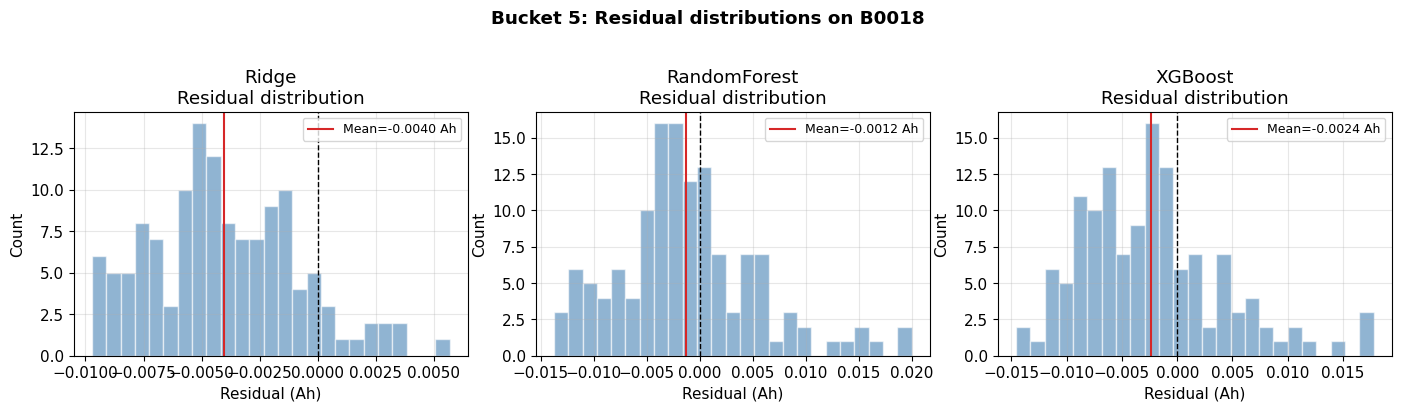

In [ ]:
# Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, ["Ridge", "RandomForest", "XGBoost"]):
    resid  = y_true - holdout_results[name]["y_pred"]
    colors = np.where(cycles_test <= 44,  "#1f77b4",
             np.where(cycles_test <= 88,  "#2ca02c", "#d62728"))

    ax.hist(resid, bins=25, color="steelblue", alpha=0.6, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
    ax.axvline(resid.mean(),color="#d62728",linewidth=1.5,
               linestyle="-", label=f"Mean={resid.mean():.4f} Ah")
    ax.set_xlabel("Residual (Ah)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}\nResidual distribution")
    ax.legend(fontsize=9)

plt.suptitle("Bucket 5: Residual distributions on B0018",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./assets/plot8_residual_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#### Final Model
Decision criteria (in priority order):
  1. Explainability: SHAP must explain genuine degradation patterns, not memorised training artefacts
  2. Generalisation: low train→val overfitting ratio
  3. Holdout RMSE: performance on unseen battery

Ridge:
  + Lowest B0018 RMSE (0.0051 Ah), lowest val/train ratio (4.8×)
  + Residuals show interpretable systematic bias (inter-battery offset)
  - Coefficients already interpretable as a result SHAP adds limited insight
  - Cannot capture non-linear interactions between features

XGBoost (tuned):
  + Native TreeSHAP: exact, fast, captures interaction effects
  + Non-linear: can model the knee point and recovery bump dynamics
  - Train→val ratio 41× before tuning — must verify tuned ratio < 10×
  - SHAP explanations only valid if overfitting is resolved
""")

# MODEL EXPLAINABILITY

# DEPLOYMENT